<a href="https://colab.research.google.com/github/ivymist/eple/blob/main/8_ende_auto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Practical 8**

**Performing encoding and decoding of images using deep autoencoder**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
def load_imgs_from_folder(folder_path, img_size=(64,64)):
    imgs = []

    for person in os.listdir(folder_path):
        person_path = os.path.join(folder_path, person)

        if os.path.isdir(person_path):  # check it's a folder
            for filename in os.listdir(person_path):

                img_path = os.path.join(person_path, filename)

                img = load_img(img_path, target_size=img_size, color_mode="rgb")
                img_array = img_to_array(img) / 255.0

                imgs.append(img_array)

    return np.array(imgs)

In [ ]:
data_folder = "/content/drive/MyDrive/Celebrity Faces Dataset"
xtrain=load_imgs_from_folder(data_folder)
xtest=xtrain[:10]

In [ ]:
if xtrain.shape[-1]!=3:
  raise ValueError("Input imgs must have 3 channels (RGB), but found shape: "+str(xtrain.shape))

In [ ]:
def build_autoencoder(in_shape=(64, 64, 3)):
  en_inp=layers.Input(shape=in_shape)
  x=layers.Conv2D(32, (3, 3), activation='relu', padding='same')(en_inp)
  x=layers.MaxPooling2D((2, 2), padding='same')(x)
  x=layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  x=layers.MaxPooling2D((2, 2), padding='same')(x)
  x=layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
  encoded=layers.MaxPooling2D((2, 2), padding='same')(x)

  dec_inp=layers.Input(shape=(8, 8, 128))
  x=layers.Conv2D(128, (3, 3), activation='relu', padding='same')(dec_inp)
  x=layers.UpSampling2D((2, 2))(x)
  x=layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  x=layers.UpSampling2D((2, 2))(x)
  x=layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x=layers.UpSampling2D((2, 2))(x)
  decoded=layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

  encoder=models.Model(en_inp, encoded)
  decoder=models.Model(dec_inp, decoded)

  autoencoder=models.Model(en_inp, decoder(encoded))
  autoencoder.compile(optimizer='adam', loss='mse')

  return autoencoder, encoder, decoder

In [ ]:
def display_imgs(autoencoder, xtest, n_imgs=5):
  decoded_imgs=autoencoder.predict(xtest[:n_imgs])
  fig, axes=plt.subplots(2, n_imgs, figsize=(10, 4))
  for i in range(n_imgs):
    axes[0, i].imshow(xtest[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(decoded_imgs[i])
    axes[1, i].axis('off')
  plt.show()

In [ ]:
autoencoder, encoder, decoder=build_autoencoder()
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 64, 64, 3)      │       240,707 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.fit(xtrain, xtrain, epochs=5, batch_size=64, validation_data=(xtest, xtest))

Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - loss: 0.0639 - val_loss: 0.0417
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0304 - val_loss: 0.0231
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0221 - val_loss: 0.0197
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0190 - val_loss: 0.0163
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0176 - val_loss: 0.0155


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step


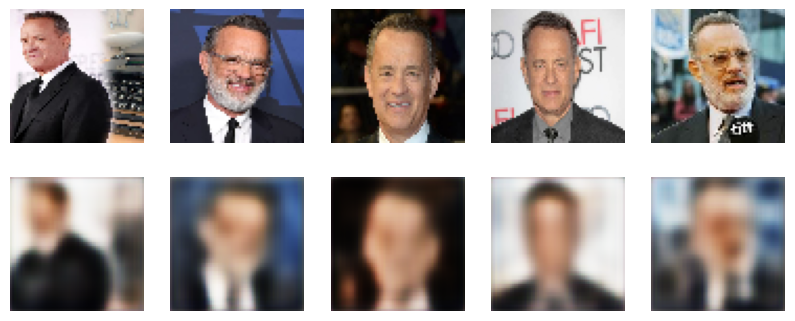

In [ ]:
display_imgs(autoencoder, xtest)

In [ ]:
autoencoder.save('demo-autoencoder-for-celeb.h5')